# Exploratory Data Analysis (EDA)

**Input:**
* `rccarbonation.xlsx` (Raw dataset)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
try:
    df = pd.read_excel('rccarbonation.xlsx')
    
    # Apply the same preprocessing/mapping as the Training Notebook
    # This ensures we analyze the data exactly as the model sees it
    mapping_dict = {
        r'\bPIA\b': '0', r'\bUEA\b': '1', r'\bPEA\b': '2',
        r'\bCPII Z\b': '0', r'\bCPV - ARI\b': '1', r'\bCPIV\b': '2',
        r'\bCPII F\b': '3', r'\bCPIII\b': '4', r'\bCPII E\b': '5',
    }
    df.replace(mapping_dict, regex=True, inplace=True)
    
    # Ensure numeric types for correlation calculation
    for col in ['Exposure conditions', 'Type of cement']:
        df[col] = pd.to_numeric(df[col])

    print("Data loaded successfully. Shape:", df.shape)
    display(df.head())

except FileNotFoundError:
    print("ERROR: File 'rccarbonation.xlsx' not found.")

Data loaded successfully. Shape: (20000, 7)


,CCO₂ (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),Possan
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178


### 1. Descriptive Statistics

Here we examine the central tendency (mean, median) and dispersion (standard deviation) of the data.

In [4]:
# Display summary statistics transposed for better readability
stats = df.describe().T
display(stats)

,count,mean,std,min,25%,50%,75%,max
CCO₂ (%),20000.0,0.164796,0.078089,0.03,0.10000,0.16000,0.23000,0.3000
fc (MPa),20000.0,34.900490,8.662669,20.00,27.40000,34.80000,42.40000,50.0000
RH (%),20000.0,59.939055,17.305382,30.00,44.90000,60.10000,74.90000,90.0000
Type of cement,20000.0,2.506900,1.705725,0.00,1.00000,3.00000,4.00000,5.0000
Exposure conditions,20000.0,0.992100,0.816377,0.00,0.00000,1.00000,2.00000,2.0000
t (years),20000.0,49.933550,29.320048,0.00,24.00000,50.00000,75.00000,100.0000
Possan,20000.0,16.591604,12.842477,0.00,7.79345,13.21595,21.53135,119.7121


### 2. Correlation Analysis

The Heatmap below visualizes the Pearson correlation coefficients between variables.
* **Positive values (blue):** Indicate a direct relationship (e.g., as Time increases, Carbonation Depth increases).
* **Negative values (red):** Indicate an inverse relationship (e.g., higher Compressive Strength reduces Carbonation).

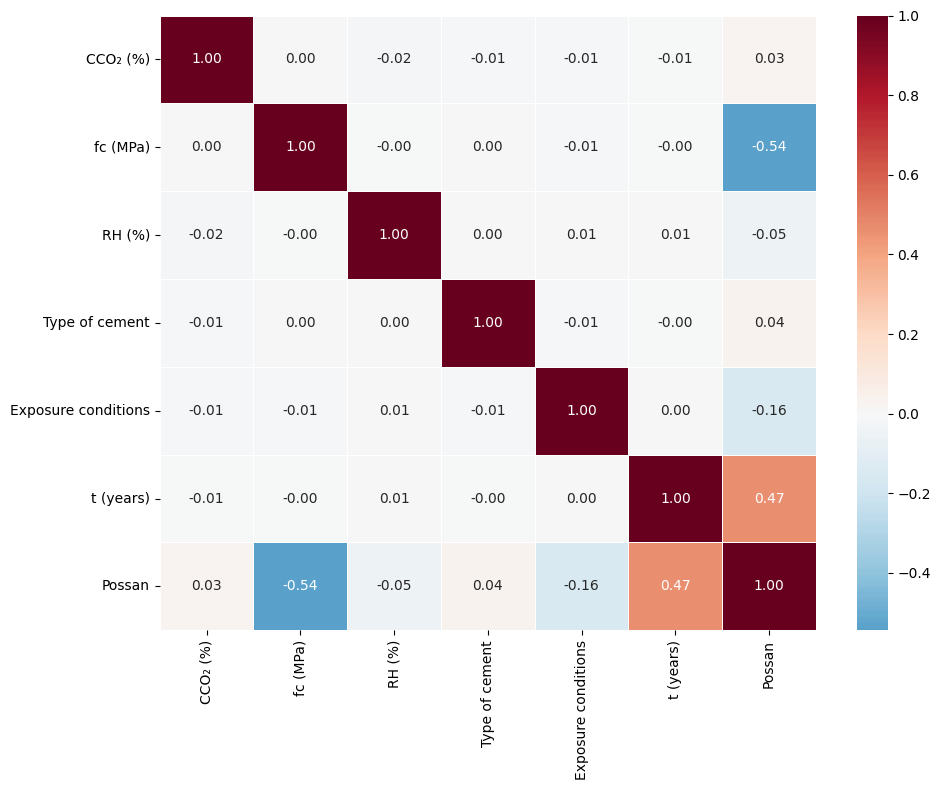

In [5]:
plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = df.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r',     # Red-Blue colormap
            center=0, 
            linewidths=0.5, 
            linecolor='white')


plt.tight_layout()
plt.show()

### 3. Feature vs. Target Analysis

Scatter plots allow us to visualize the specific relationship between each input feature and the target variable (**Carbonation Depth**).
We focus on key factors: Time ($t$), $CO_2$ Concentration, Relative Humidity ($RH$), and Compressive Strength ($f_{ck}$).

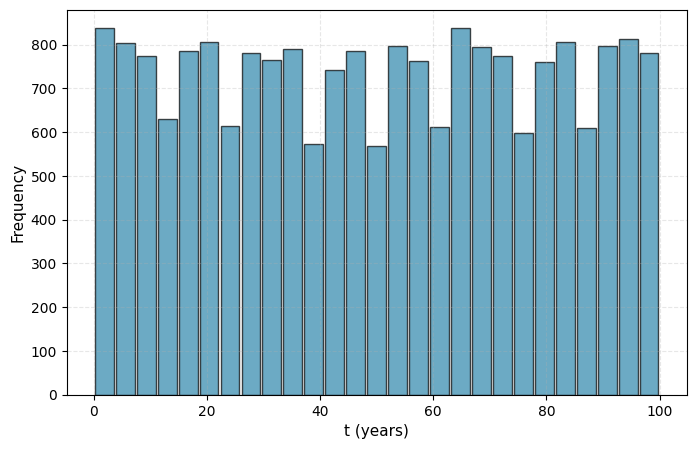

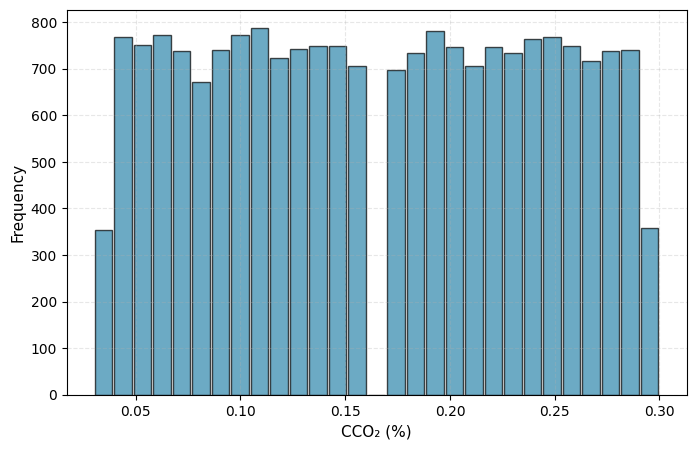

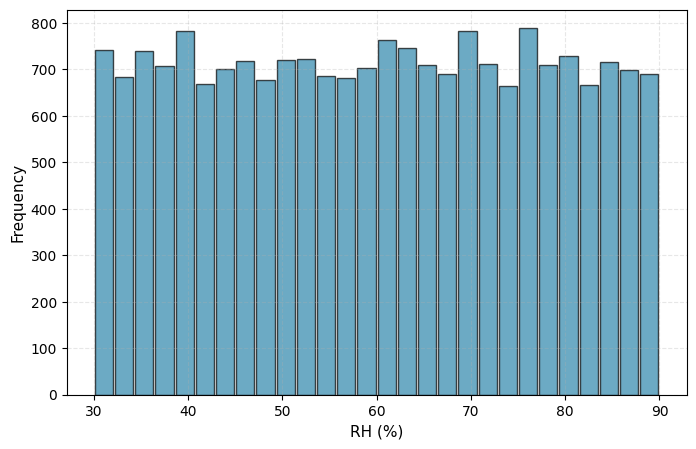

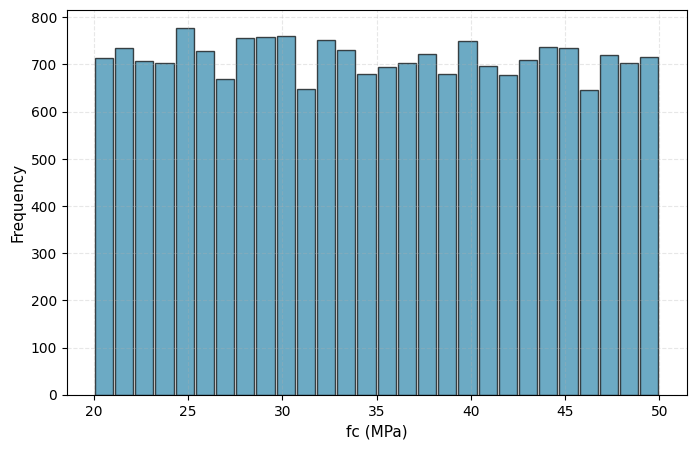

In [ ]:
import matplotlib.pyplot as plt

def plot_histogram(df, col):
    """
    Plots a histogram to analyze the distribution of a feature.
    """
    plt.figure(figsize=(8, 5))
    
    # Create histogram 
    # bins='auto' allows matplotlib to determine the optimal number of bins
    plt.hist(df[col], 
             bins='auto',         
             color='#2E86AB',     
             edgecolor='k',       
             alpha=0.7,           
             rwidth=0.9)          
    
    plt.xlabel(col, fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    
    # filename = f"hist_{col.split(' ')[0]}.png"
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()

# List of features to analyze
features = ['t (years)', 'CCO₂ (%)', 'RH (%)', 'fc (MPa)']

for feature in features:
    plot_histogram(df, feature)

### 4. Carbonation Profile Modeling and $k$-Coefficient 
CalculationThe following script performs the segmentation of the dataset based on exposure conditions (Indoor vs. Outdoor) and compressive strength classes (C20–C50). For each subset, it calculates the experimental carbonation coefficient ($k$) by fitting the theoretical square-root-of-time law ($x = k\sqrt{t}$) to the observed data. 

Plotting Indoor Graph...


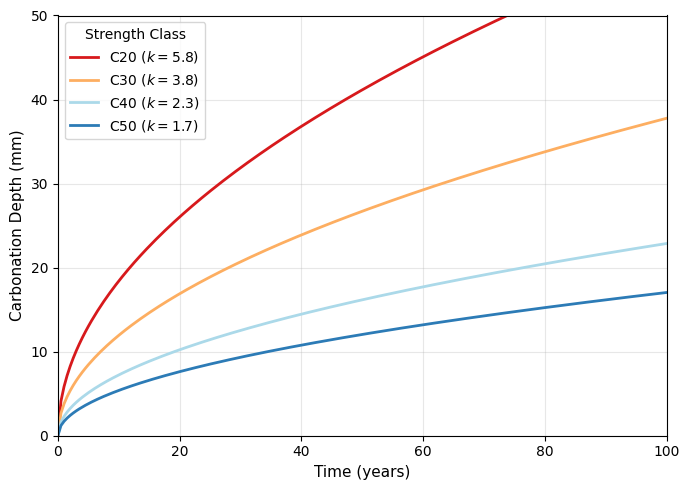

Plotting Outdoor Graph...


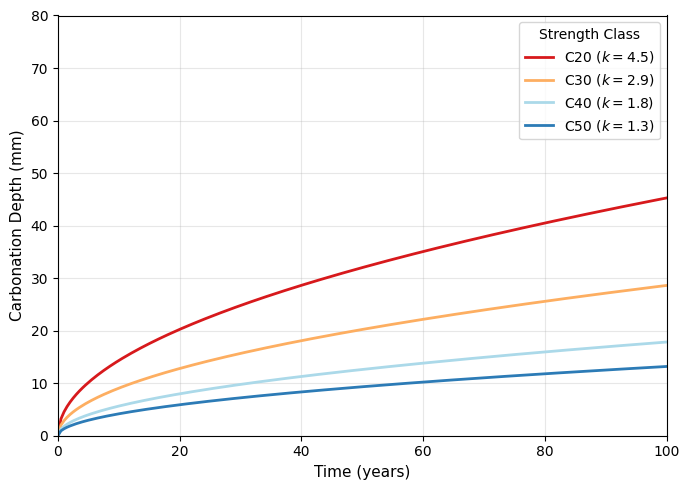


Calculated k values:
Indoor: {'C20': np.float64(5.821053597638522), 'C30': np.float64(3.777760025124636), 'C40': np.float64(2.2874386194048375), 'C50': np.float64(1.7044813194142585)}
Outdoor: {'C20': np.float64(4.527516149150697), 'C30': np.float64(2.8614401034971033), 'C40': np.float64(1.7839583279332396), 'C50': np.float64(1.3186971229755808)}


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carbonation Law Function (y = k * sqrt(t))
def carbonation_law(t, k):
    return k * np.sqrt(t)

# 2. Create Strength Classes (Binning)
# Ensure your 'df' is already loaded before running this
bins = [15, 25, 35, 45, 55, 100]
labels = ['C20', 'C30', 'C40', 'C50', 'C60+']
df['Class_C'] = pd.cut(df['fc (MPa)'], bins=bins, labels=labels)

# 3. Function to Plot Profiles (NO TITLE)
def plot_profiles(exposure_code, filename, ax_limit=60):
    plt.figure(figsize=(7, 5))
    
    # Filter by exposure condition
    subset = df[df['Exposure conditions'] == exposure_code] 
    
    colors = {'C20': '#d7191c', 'C30': '#fdae61', 'C40': '#abd9e9', 'C50': '#2c7bb6'}
    k_values = {}

    t_line = np.linspace(0, 100, 200)

    for strength_class in ['C20', 'C30', 'C40', 'C50']:
        class_data = subset[subset['Class_C'] == strength_class]
        
        if len(class_data) > 0:
            # Calculate average k
            valid_data = class_data[class_data['t (years)'] > 0]
            # Note: 'Possan' refers to the observed carbonation depth column
            k_experimental = (valid_data['Possan'] / np.sqrt(valid_data['t (years)'])).mean()
            k_values[strength_class] = k_experimental
            
            # Plot the Fitted Curve
            y_model = carbonation_law(t_line, k_experimental)
            plt.plot(t_line, y_model, label=f'{strength_class} ($k={k_experimental:.1f}$)', 
                     color=colors.get(strength_class, 'gray'), linewidth=2)

    
    plt.xlabel('Time (years)', fontsize=11)
    plt.ylabel('Carbonation Depth (mm)', fontsize=11)
    plt.xlim(0, 100)
    plt.ylim(0, ax_limit)
    plt.legend(title='Strength Class')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    return k_values

# Execution (0=Indoor/Sheltered, 2=Outdoor/Exposed)
print("Plotting Indoor Graph...")
k_indoor = plot_profiles(exposure_code=0, 
                         filename='indoor_profiles.png', 
                         ax_limit=50)

print("Plotting Outdoor Graph...")
k_outdoor = plot_profiles(exposure_code=2, 
                          filename='outdoor_profiles.png',
                          ax_limit=80)

print("\nCalculated k values:")
print("Indoor:", k_indoor)
print("Outdoor:", k_outdoor)